In [20]:
import numpy as np
import matplotlib.pyplot as plt

def setup_tridiagonal_matrix(x, y):

    n = len(x)

    h = np.diff(x)  # Step sizes between data points

    # Initialize the tridiagonal matrix coefficients

    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector

    # Populate the tridiagonal matrix coefficients

    for i in range(1, n - 1):

        A[i - 1] = h[i-1]             # Subdiagonal
        B[i - 1] = 2 * (h[i-1] + h[i])       # Main diagonal
        C[i - 1] = h[i]             # Superdiagonal
        D[i - 1] = 6 * ((y[i+1] -y[i])/h[i] - (y[i]-y[i-1])/h[i-1])             # Right-hand side vector

    return A, B, C, D

# Example data points

x = np.array([0, 1, 2, 3, 4, 5])

y = np.array([0, 1, 0, 1, 0, 1])

 

# Set up the tridiagonal matrix for the cubic spline

A, B, C, D = setup_tridiagonal_matrix(x, y)

 

print("Subdiagonal (A):", A)

print("Main diagonal (B):", B)

print("Superdiagonal (C):", C)

print("Right-hand side (D):", D)

Subdiagonal (A): [1. 1. 1. 1.]
Main diagonal (B): [4. 4. 4. 4.]
Superdiagonal (C): [1. 1. 1. 1.]
Right-hand side (D): [-12.  12. -12.  12.]


In [21]:
import numpy as np
def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

In [32]:
def evaluate_spline(x_data, y_data, M, x_query):
    """M: second derivatives; M[0]=M[-1]=0 for natural spline"""
    n = len(x_data)
    h = np.diff(x_data) # step sizes
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)
    S = (
        (M[i] / (6*hi)) * dx_right**3 + # Term 1
        (M[i+1] / (6*hi)) * dx_left**3 + # Term 2
        (y_data[i] /hi - M[i] *hi/6) * dx_right + # Term 3
        (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left # Term 4
    )
    return S


In [56]:
x_data = np.array([i for i in range(50)])
x_query = np.linspace(x_data[0], x_data[-1], 100)
y_data = np.random.uniform(low=-10,high=10,size=50)
A,B,C,D = setup_tridiagonal_matrix(x_data,y_data)
x = thomas_algorithm(A,B,C,D)
M = np.zeros(len(y_data))
M[1:-1] = x
print(len(M))
y_query  = [evaluate_spline(x_data,y_data,M,x_i) for x_i in x_query]
print(len(y_query))

50
100


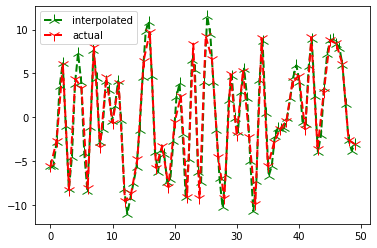

In [58]:
##Interpolated points
plt.plot(x_query, y_query, color='green', marker='2', linestyle='dashed',
     linewidth=2, markersize=12, label="interpolated")
plt.plot(x_data, y_data, color='red', marker='1', linestyle='dashed',
     linewidth=2, markersize=12,label="actual")
plt.legend()